<a href="https://colab.research.google.com/github/dtoralg/TheValley_MDS/blob/main/%5B00%5D%20-%20Workshop%20Modelizacion%20II/Workshop_Modelizacion_II_RESUELTO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Workshop de Modelos Supervisados II: Mantenimiento predictivo**


 ## **Presentación del caso de uso de negocio**

 Nuestra empresa es el referente europeo en fabricación de aeronaves, y busca lanzar una nueva línea de montaje para fabricar piezas aeronáuticas, hechas con materiales compuestos. El corazón de este proceso son 10 cabezales de inyección que deben funcionar con precisión y fiabilidad. Sin embargo, sabemos que no todos los cabezales tendrán el mismo rendimiento: algunos fallarán antes de lo esperado, y un fallo en plena producción podría generar retrasos costosos, desperdicio de materiales y problemas de calidad.

Para anticipar y evitar dichos impactos, el responsable del equipo de producción ha solicitado que, desde el departamento de Advanced Analytics, seamos capaces de predecir qué cabezales fallarán.

Nuestro reto es anticiparnos a esos fallos antes de que ocurran. Desde el área de mantenimiento nos han facilitado datos históricos de rendimiento y condiciones de operación, con los que tendremos que construir un modelo de predicción que nos permita identificar cuáles de esos cabezales tienen más probabilidades de fallar durante su vida útil. Así podremos seleccionar solo los más fiables para nuestra nueva línea de montaje, asegurando eficiencia y calidad desde el primer día.

Este es el componente que vamos a ayudar a fabricar, una piel de avión fabricada en material compuesto:

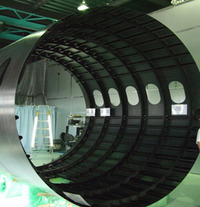


Imagen ilustrativa de los cabezales que tejen la fibra de carbono, a modo de referencia:

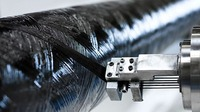

## **Dataset**

El conjunto de datos consta de 10,000 filas y 14 columnas. Las columnas contienen la siguiente información:

- `UID`: Identificador único que varía de 1 a 10,000.
- `productID`: Compuesto por una letra L, M o H para las variantes de calidad del producto: baja (50% de todos los productos), media (30%) y alta (20%), junto con un número de serie específico de la variante.
- `temperatura del aire [K]`: Generada usando un proceso de 'caminata aleatoria', luego normalizada a una desviación estándar de 2 K alrededor de 300 K.
- `temperatura del proceso [K]`: Generada usando un proceso de 'caminata aleatoria' normalizado a una desviación estándar de 1 K, sumada a la temperatura del aire más 10 K.
- `velocidad de rotación [rpm]`: Calculada a partir de una potencia de 2860 W, superpuesta con un ruido distribuido normalmente.
- `par motor [Nm]`: Los valores de torque están distribuidos normalmente alrededor de 40 Nm con un σ = 10 Nm y no presentan valores negativos
-`desgaste de herramienta [min]`: Las variantes de calidad H/M/L añaden 5/3/2 minutos de desgaste de la herramienta utilizada en el proceso.
-`Target`: Indica si la máquina ha fallado o no
- `Tipo de fallo`: *No Failure*,*Heat Dissipation Failure*, *Power Failure*,*Overstrain Failure*,*Tool Wear Failure*,*Random Failures*

##**Plan de Trabajo**

1. **Análisis Exploratorio de Datos (EDA)**
   - Identificación de tipos de variables (categóricas, numéricas, etc.).
   - Detección y manejo de valores faltantes (si los hay).
   - Análisis de la distribución de la variable objetivo y de las características.
   - Visualizaciones:
     - Análisis de correlaciones.
     - Identificación de outliers.
     - Relación entre variables mediante gráficos.

2. **Modelado Inicial**
   - Preparación de las variables (codificación, divisón en entrenamiento y prueba, escalado, etc.).
   - Entrenamiento inicial con un modelo sencillo

3. **Evaluación Inicial**
   - Evaluación del modelo inicial con las métricas más adecuadas dada la naturaleza del problema.

4. **Entrenamiento utilizando distintos modelos**
   - Entrenamiento de modelos más complejos.
   - Evaluación de los diferentes modelos y comparación de las métricas obtenidas.

5. **Optimización de Hiperparámetros**
   - Búsqueda de los mejores hiperparámetros para cada modelo utilizando técnicas como GridSearch o RandomSearch.

6. **Comparación de Resultados**
   - Evaluación y comparación de los resultados de todos los modelos.
   - Selección del modelo con el mejor rendimiento basado en las métricas obtenidas (una vez ajustados los hiperparámetros).

7. **Visualización de los Resultados**
   - Variables más relevantes para el modelo seleccionado.
   - Análisis Univariante de las variables usando las predicciones.

8. **(EXTRA) ¿Cómo resolveríais el problema si queréis predecir qué tipo de fallo va a ocurrir? ¿Qué cambia respecto al caso anterior?**
   



**¡A por ello!** ✈️

## 0. Carga de librerías y de datos

In [ ]:
# Cargamos las librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [ ]:
# Leemos el dataframe
failure = pd.read_csv("https://raw.githubusercontent.com/JimenaAreta/thevalley-MDS/refs/heads/jimena/datasets/predictive_maintenance.csv")

In [ ]:
failure.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


## 1. Análisis exploratorio de los datos (EDA)

### 1.1 Descriptivo de las variables

In [ ]:
# Número de filas y de columnas
print(f"El dataset tiene {failure.shape[0]} filas y {failure.shape[1]} columnas")

El dataset tiene 10000 filas y 10 columnas


In [ ]:
# Nombre de las columnas
print(f"Las columnas del dataset son: {failure.columns}")

Las columnas del dataset son: Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target', 'Failure Type'],
      dtype='object')


In [ ]:
# Tipo de variables
failure.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [ ]:
# Tenemos dos variables que no aportan información (UDI, Product ID) - las eliminamos
failure = failure.drop(['UDI', 'Product ID'], axis=1)

### 1.2 Nulos

In [ ]:
failure.isnull().sum()

,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Target,0
Failure Type,0


### 1.3 Valores duplicados

In [ ]:
def count_duplicate_rows(df):
    duplicate_rows = df[df.duplicated()]

    if not duplicate_rows.empty:
        print("Duplicate rows found in the dataframe.")
        count = len(duplicate_rows)
        print(f"Count of duplicate rows: {count}.")
    else:
        print("No duplicate rows found in the dataframe.")

    return df

num_duplicates = count_duplicate_rows(failure)

No duplicate rows found in the dataframe.


### 1.3 Descriptivo estadístico

In [ ]:
failure.describe(include='all')

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000
unique,3,NaN,NaN,NaN,NaN,NaN,NaN,6
top,L,NaN,NaN,NaN,NaN,NaN,NaN,No Failure
freq,6000,NaN,NaN,NaN,NaN,NaN,NaN,9652
mean,NaN,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,NaN
std,NaN,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,NaN
min,NaN,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,NaN
25%,NaN,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,NaN
50%,NaN,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,NaN
75%,NaN,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,NaN


### 1.4 Visualizaciones

#### 1.4.1 Distribución del target

In [ ]:
failure['Target'].value_counts(normalize=True)

,proportion
Target,
0,0.9661
1,0.0339


/tmp/ipython-input-12-3475509553.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Target', data=failure, palette=['skyblue', 'salmon'])


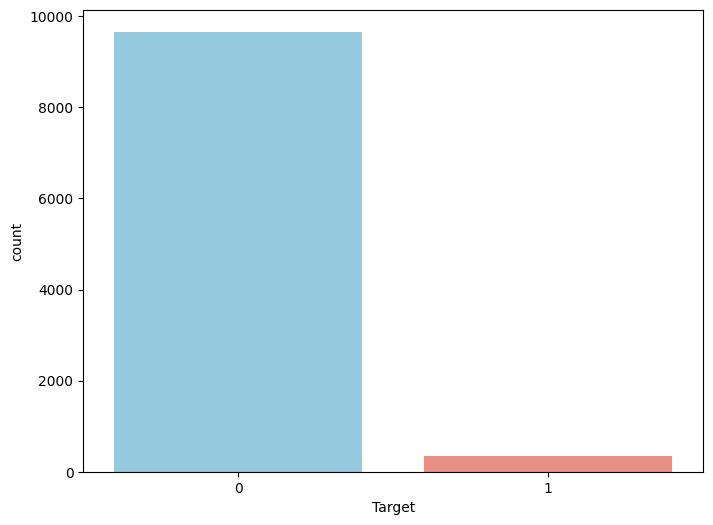

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Target', data=failure, palette=['skyblue', 'salmon'])

Los datos están desbalanceados (97% - 3%)

In [ ]:
# ¿Cómo se distribuyen los distintos tipos de fallos?
failure['Failure Type'].value_counts(normalize=True)

,proportion
Failure Type,
No Failure,0.9652
Heat Dissipation Failure,0.0112
Power Failure,0.0095
Overstrain Failure,0.0078
Tool Wear Failure,0.0045
Random Failures,0.0018


In [ ]:
# Mirándolo respecto del target
failure[['Target','Failure Type']].value_counts(normalize=True)

Target  Failure Type            
0       No Failure                  0.9643
1       Heat Dissipation Failure    0.0112
        Power Failure               0.0095
        Overstrain Failure          0.0078
        Tool Wear Failure           0.0045
0       Random Failures             0.0018
1       No Failure                  0.0009
Name: proportion, dtype: float64

Tenemos datos con el tipo de fallo "Random Failures" que tiene como Target 0.

Al igual tenemos datos con tipo "No Failure" que tiene como Target 1

In [ ]:
# Vemos cuántos datos son incorrectos
failure[((failure['Target'] == 0) & (failure['Failure Type'] != 'No Failure')) | ((failure['Target'] == 1) & (failure['Failure Type'] == 'No Failure'))].count()

,0
Type,27
Air temperature [K],27
Process temperature [K],27
Rotational speed [rpm],27
Torque [Nm],27
Tool wear [min],27
Target,27
Failure Type,27


In [ ]:
# Filtramos los datos ya que son datos con el target erróneo
failure = failure[((failure['Target'] == 0) & (failure['Failure Type'] == 'No Failure')) | ((failure['Target'] == 1) & (failure['Failure Type'] != 'No Failure'))]

In [ ]:
failure.count()

,0
Type,9973
Air temperature [K],9973
Process temperature [K],9973
Rotational speed [rpm],9973
Torque [Nm],9973
Tool wear [min],9973
Target,9973
Failure Type,9973


#### 1.4.2 Relación entre las variables

In [ ]:
num_cols = failure.select_dtypes(include=['number']).drop('Target', axis=1).columns

In [ ]:
cat_cols = failure.select_dtypes(include=['object']).drop('Failure Type', axis = 1).columns

In [ ]:
num_cols

Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'],
      dtype='object')

In [ ]:
cat_cols

Index(['Type'], dtype='object')

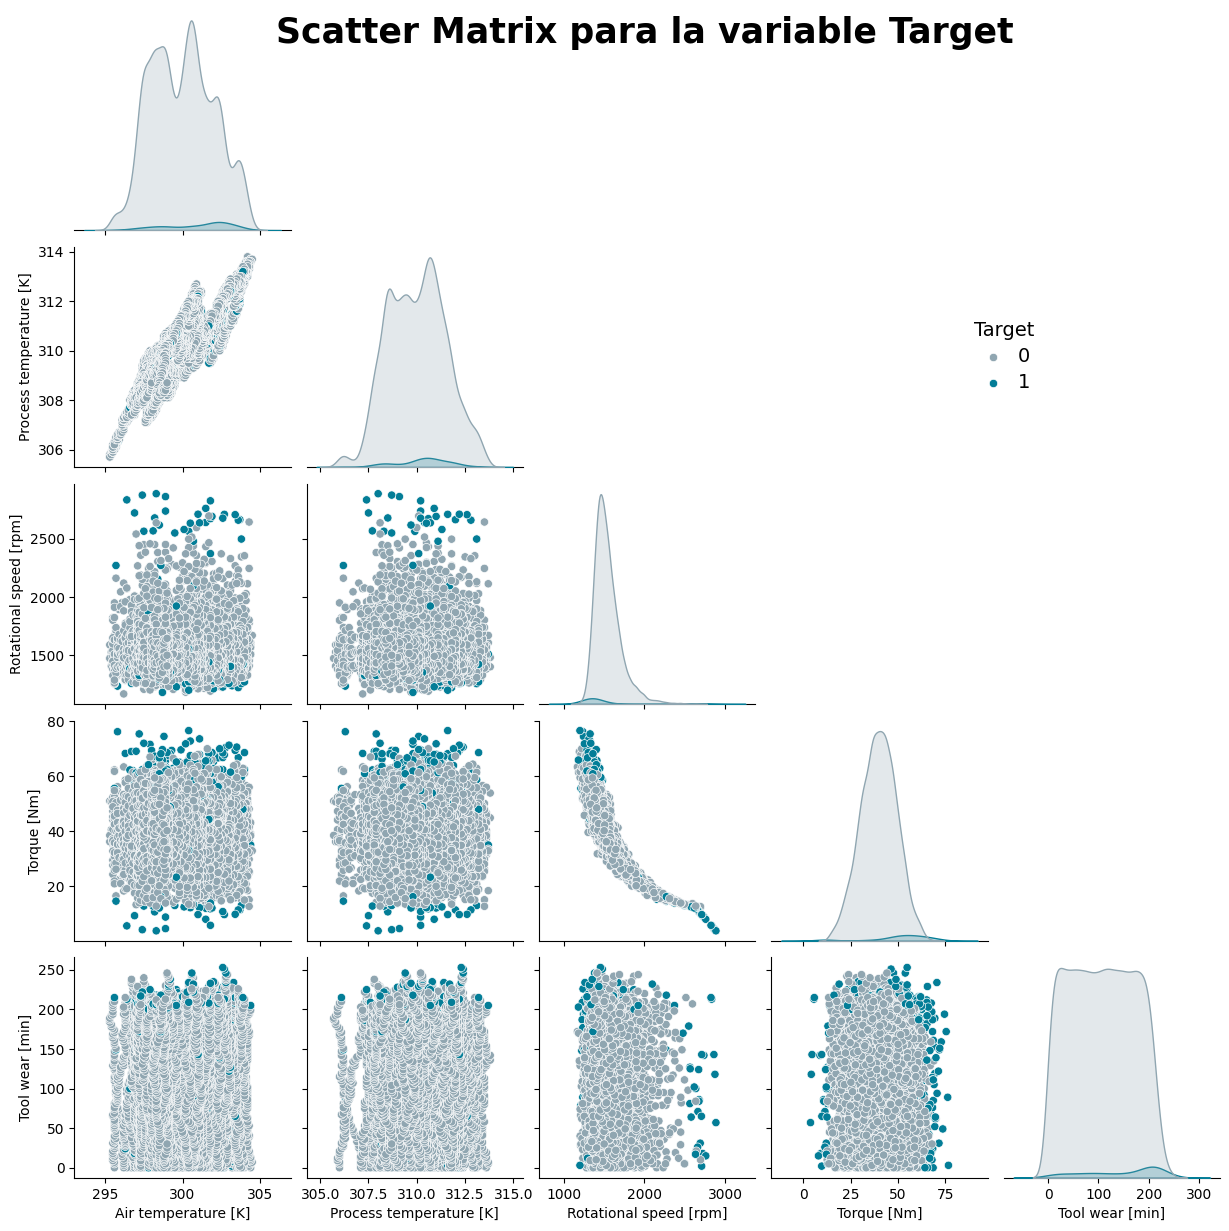

In [ ]:
c = ['#90A6B1', '#037d97']
sns.pairplot
fig = sns.pairplot(data=failure, x_vars=num_cols, y_vars=num_cols, hue='Target', corner=True, palette=c)

fig._legend.set_bbox_to_anchor((0.8, 0.7))
fig._legend.set_title('Target')
fig._legend.loc = 'upper center'
fig._legend.get_title().set_fontsize(14)
for item in fig._legend.get_texts():
    item.set_fontsize(14)

plt.suptitle(f'Scatter Matrix para la variable Target\n\n', ha='center', fontweight='bold', fontsize=25, y=0.98)
plt.show()

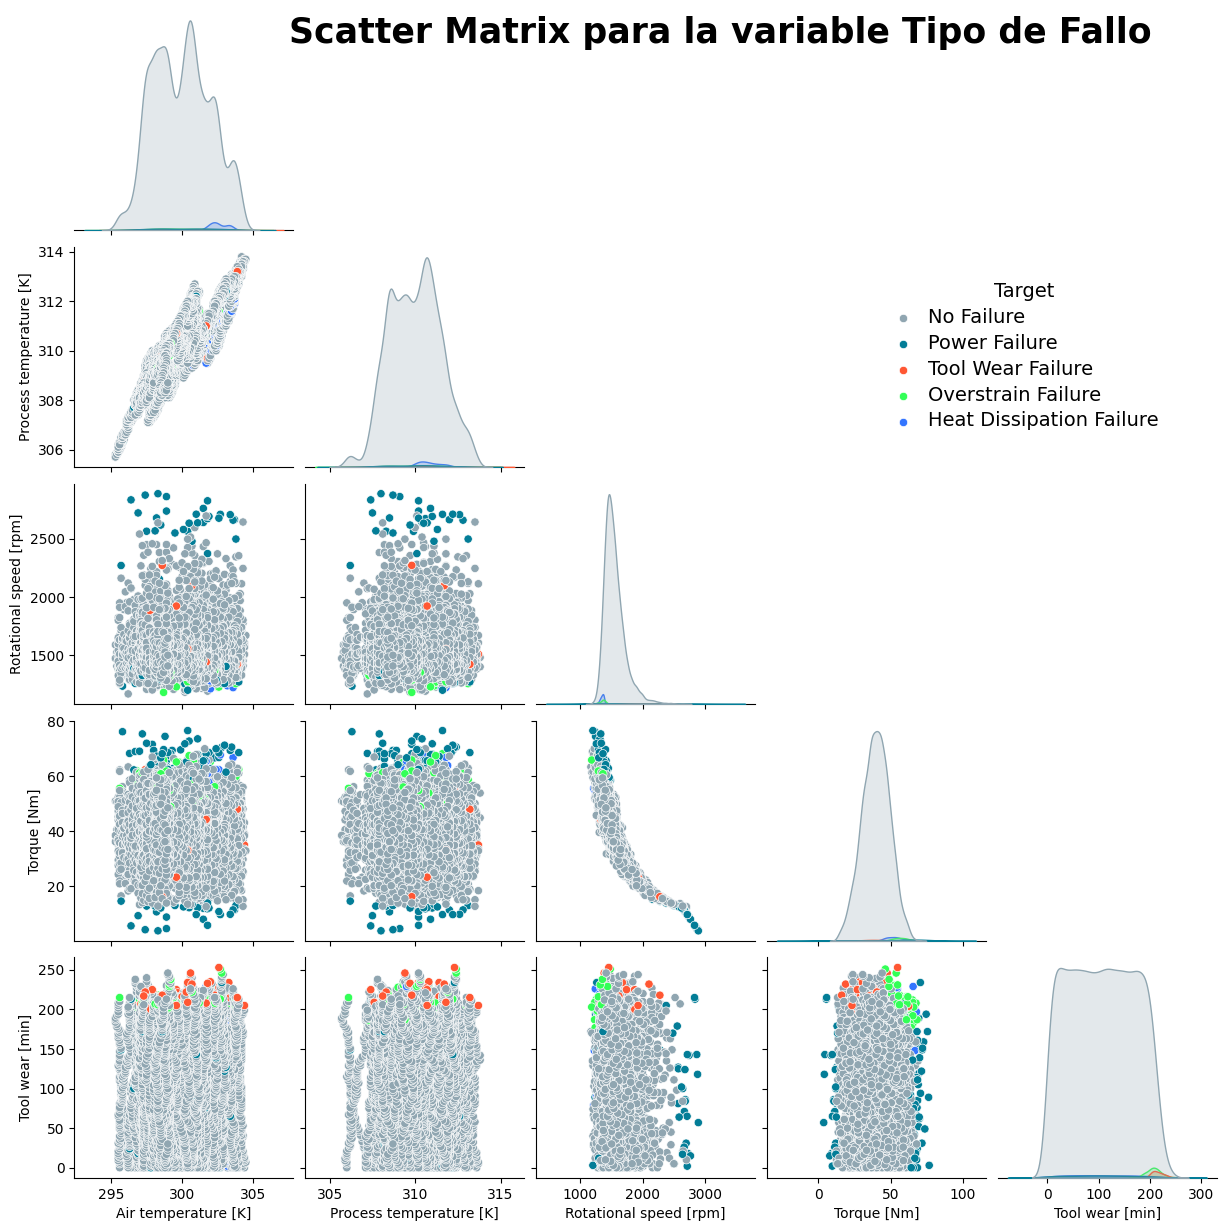

In [ ]:
c = ['#90A6B1', '#037d97', '#FF5733', '#33FF57', '#3375FF']


fig = sns.pairplot(data=failure, x_vars=num_cols, y_vars=num_cols, hue='Failure Type', corner=True, palette=c)

fig._legend.set_bbox_to_anchor((0.8, 0.7))
fig._legend.set_title('Target')
fig._legend.loc = 'upper center'
fig._legend.get_title().set_fontsize(14)
for item in fig._legend.get_texts():
    item.set_fontsize(14)

plt.suptitle(f'Scatter Matrix para la variable Tipo de Fallo\n\n', ha='center', fontweight='bold', fontsize=25, y=0.98)
plt.show()

Conclusiones:

1. Hay una relación lineal positiva entre "Air Temperature" y "Process Temperature"
2. Hay una relación lineal negativa entre "Rotational Speed" y "Torque"

#### 1.4.3 Distribuciones de las variables

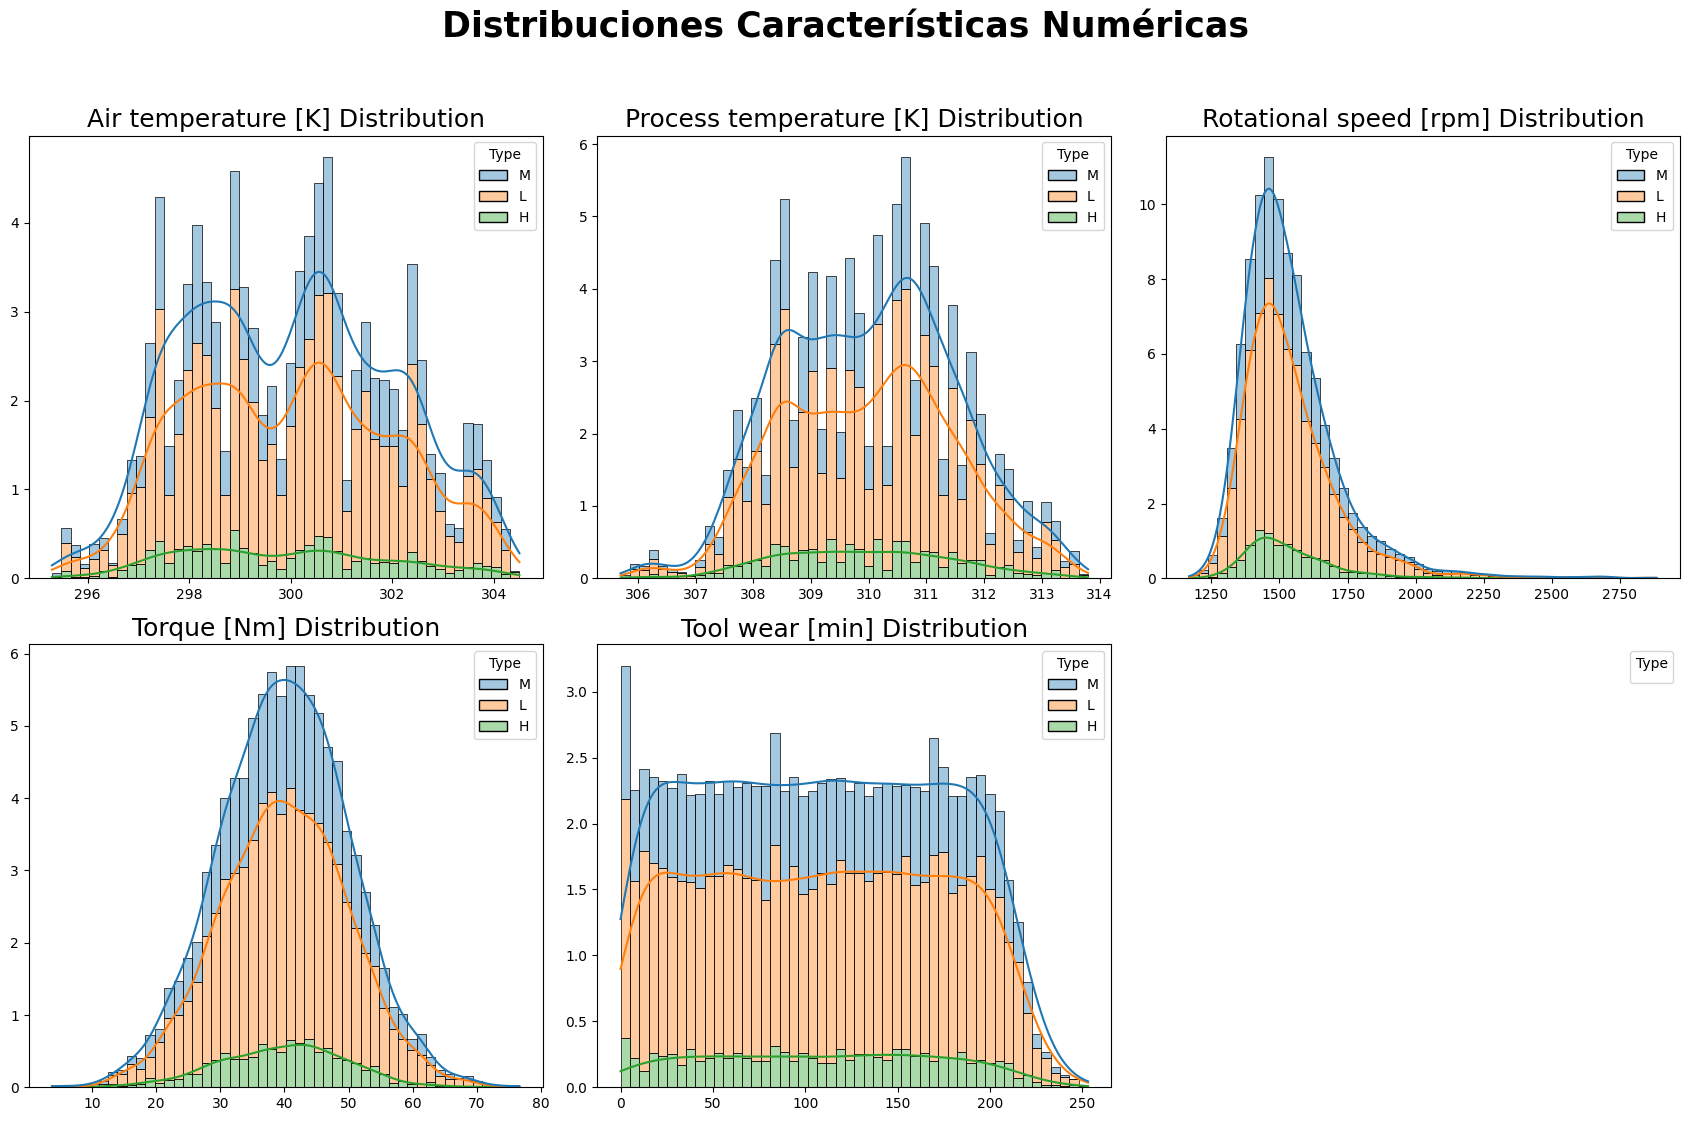

In [ ]:
palette = ['#302c36', '#037d97', '#E4591E', '#C09741',
           '#EC5B6D', '#90A6B1', '#6ca957', '#D8E3E2']

features = [f for f in failure.columns if f in num_cols]
n_bins = 50
histplot_hyperparams = {
    'kde': True,
    'alpha': 0.4,
    'stat': 'percent',
    'bins': n_bins
}

columns = features
n_cols = 3
n_rows = math.ceil(len(columns) / n_cols)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(17, 12))
ax = ax.flatten()

for i, column in enumerate(columns):
    plot_axes = [ax[i]]

    sns.histplot(
        failure,
        x=column,
        hue='Type',
        multiple="stack",
        ax=ax[i],
        color=palette[1],
        **histplot_hyperparams
    )

    for artist in plot_axes[0].artists:
        if isinstance(artist, sns.kdeplot):
            artist.remove()

    # Títulos
    ax[i].set_title(f'{column} Distribution', fontsize=18)
    ax[i].set_xlabel(None, fontsize=16)
    ax[i].set_ylabel(None, fontsize=16)

handles, labels = ax[0].get_legend_handles_labels()
plt.legend(handles, labels, title='Type')

for i in range(i + 1, len(ax)):
    ax[i].axis('off')

fig.suptitle(f'Distribuciones Características Numéricas\n\n\n', ha='center', fontweight='bold', fontsize=25, y=0.93)
plt.tight_layout()
plt.show()

Conclusiones:

1. Tanto la distribución de "Air Temperature" y "Process Temperature" son bimodales.

2. La distribución de "Rotational Speed" no es una distribución normal por lo que se podría transformar.



/tmp/ipython-input-25-767784695.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.countplot(data=failure, x='Type', palette=d)


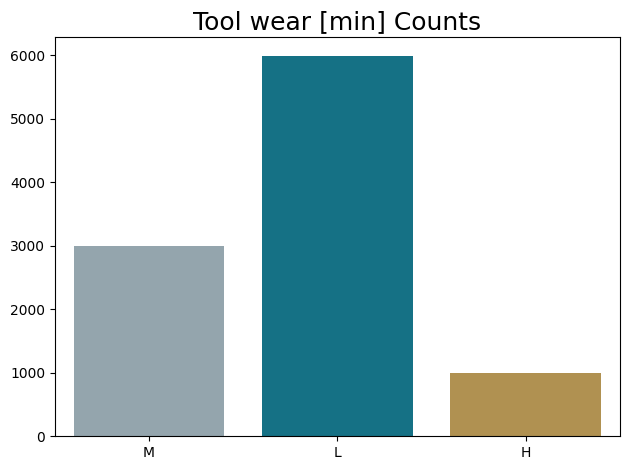

In [ ]:
d = ['#90A6B1', '#037d97', '#C09741']

columns = cat_cols

fig = sns.countplot(data=failure, x='Type', palette=d)

# Titles
fig.set_title(f'{column} Counts', fontsize=18)
fig.set_xlabel(None, fontsize=16)
fig.set_ylabel(None, fontsize=16)

plt.tight_layout()
plt.show()


#### 1.4.4 Gráfico de correlaciones

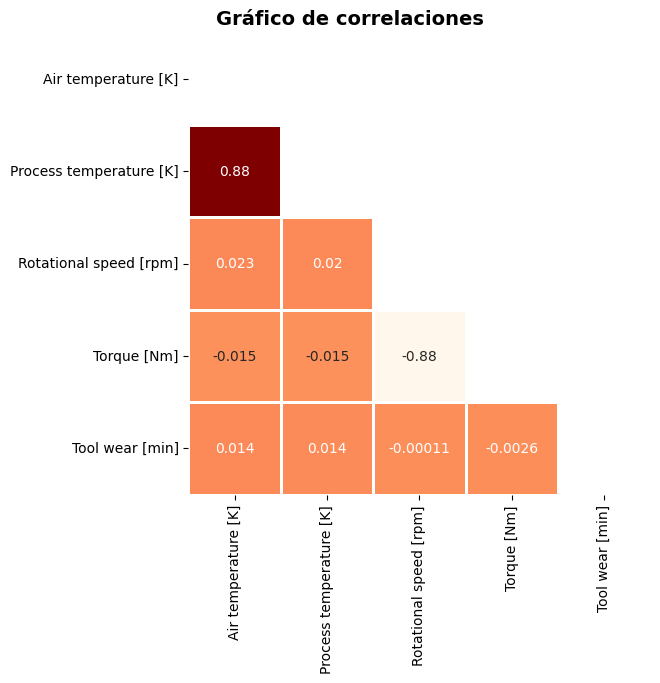

In [ ]:
corr_matrix = failure[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(corr_matrix, mask=mask, annot=True, square=True, cmap='OrRd', cbar=False, linewidths=1)
title = heatmap.set_title("Gráfico de correlaciones", weight='bold', size=14)
title.set_position([0.35, 1.05])
plt.show()

### 1.5 Normalizacion del nombre de las columnas

In [ ]:
# Eliminar caracteres de los nombres de las columnas (si no algunos modelos fallarán)
failure.columns = failure.columns.str.replace('[', '', regex=False)
failure.columns = failure.columns.str.replace(']', '', regex=False)
failure.columns = failure.columns.str.replace('<', '', regex=False)
failure.columns = failure.columns.str.replace(' ', '_', regex=False)

# Asegurar que todos los nombres de las columnas sean cadenas de texto
failure.columns = [str(col) for col in failure.columns]

# Verificar la unicidad de los nombres de las columnas
if failure.columns.duplicated().any():
    raise ValueError("Hay nombres de columnas duplicados en el DataFrame después de la limpieza.")

## 2. Modelado Inicial


### 2.1 Preparación de las variables (codificación, divisón en entrenamiento y prueba, escalado, etc.).


In [ ]:
# Importamos las librerías necesarias para el split y el escalado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Separar las características (X) y la variable objetivo (y)
X = failure.drop(['Target', 'Failure_Type'], axis=1)
y = failure["Target"]

In [ ]:
# Identificar columnas numéricas y categóricas

# Opción 1: seleccionando los nombres de las columnas manualmente
numerical_cols = ['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min']
categorical_cols = ['Type']


# Opción 2: filtrando por data type:
# numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns
# categorical_cols = X.select_dtypes(include=['object']).columns

In [ ]:
# Escalado
# Para las variables numéricas, escalamos los valores
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Para las variables categóricas, usamos codificación one-hot
X = pd.get_dummies(X, columns=categorical_cols)

In [ ]:
# División en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### 2.3 Entrenamiento inicial con un modelo sencillo

In [ ]:
# Para un problema de clasificación, el modelo más sencillo que podemos utilizar es LogisticRegression
# Importamos liberías
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support, roc_curve, auc

In [ ]:
# Entrenamiento del modelo
model = LogisticRegression(class_weight='balanced')  # Ajuste para datos desbalanceados
model.fit(X_train, y_train)

# Predicciones y probabilidades para el modelo inical
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

## 3. Evaluación Inicial

Evaluación del modelo inicial con las métricas más adecuadas dada la naturaleza del problema.




In [ ]:
# Evaluación del modelo
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.81      0.89      1929
           1       0.14      0.86      0.24        66

    accuracy                           0.81      1995
   macro avg       0.57      0.84      0.56      1995
weighted avg       0.97      0.81      0.87      1995

Confusion Matrix:
 [[1567  362]
 [   9   57]]


In [ ]:
# Como los datos están desbalanceados (97% - 3%) tenemos que añadir métricas adicionales para evaluar el modelo correctamente:
# Evaluar métricas adicionales para desbalanceo
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
# El parámetro average = 'binary' indica a la función que debe centrarse únicamente en la clase positiva (1)

print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))

Precision: 0.136
Recall: 0.864
F1-Score: 0.235


* La precisión (0.123) indica que el modelo tiene un **alto número de falsos positivos.**
* El recall (0.847) es alto, lo que significa que **el modelo es capaz de identificar la mayoría de los casos positivos**.
* Sin embargo, el F1-Score (0.216) muestra que hay un desequilibrio entre precisión y recall, sugiriendo que **el modelo necesita ajustes** para mejorar el balance entre ambos.

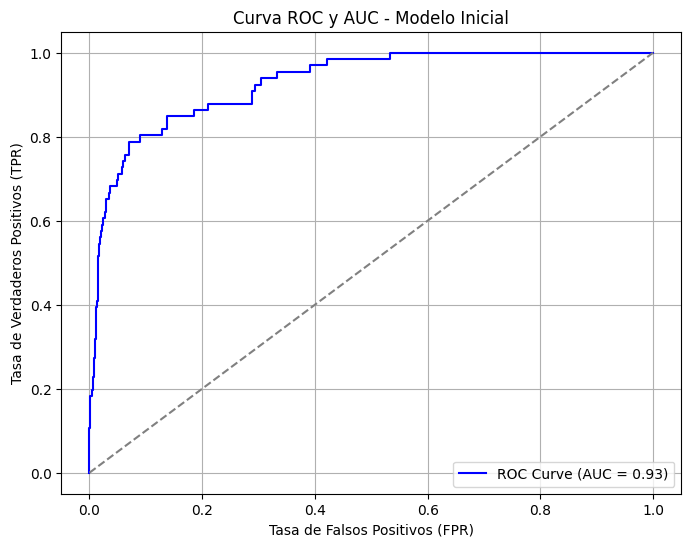

In [ ]:
# La curva ROC muestra el rendimiento del modelo para diferentes umbrales de clasificación. El AUC mide la capacidad del modelo para separar las clases y valores más altos indican mejor rendimiento.#
# Curva ROC y AUC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Curva ROC y AUC - Modelo Inicial')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


## 4. Entrenamiento utilizando distintos modelos

Preparamos 3 modelos: RandomForest, Bagging y Boosting.

Es importante recordar que los datos están desbalanceados y deberemos transmitírselo a los modelos mediante el parámetro ```average = 'binary'```

In [ ]:
# Importar librerías necesarias
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

### 4.1 Entrenamiento de modelos más complejos.

In [ ]:
# Modelo 1: Random Forest
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
precision_rf, recall_rf, f1_rf, _ = precision_recall_fscore_support(y_test, y_pred_rf, average='binary')

In [ ]:
# Modelo 2: Bagging
bagging_model = BaggingClassifier(random_state=42)
bagging_model.fit(X_train, y_train)
y_pred_bagging = bagging_model.predict(X_test)
y_prob_bagging = bagging_model.predict_proba(X_test)[:, 1]
precision_bag, recall_bag, f1_bag, _ = precision_recall_fscore_support(y_test, y_pred_bagging, average='binary')

In [ ]:
# Modelo 3: Boosting (Gradient Boosting)
boosting_model = GradientBoostingClassifier(random_state=42)
boosting_model.fit(X_train, y_train)
y_pred_boosting = boosting_model.predict(X_test)
y_prob_boosting = boosting_model.predict_proba(X_test)[:, 1]
precision_boost, recall_boost, f1_boost, _ = precision_recall_fscore_support(y_test, y_pred_boosting, average='binary')

 ### 4.2 Evaluación de los diferentes modelos y comparación de las métricas obtenidas.

In [ ]:
# Comparación gráfica de las métricas
metrics = pd.DataFrame({
    'Modelo': ['Random Forest', 'Bagging', 'Boosting'],
    'Precision': [precision_rf, precision_bag, precision_boost],
    'Recall': [recall_rf, recall_bag, recall_boost],
    'F1-Score': [f1_rf, f1_bag, f1_boost]
})

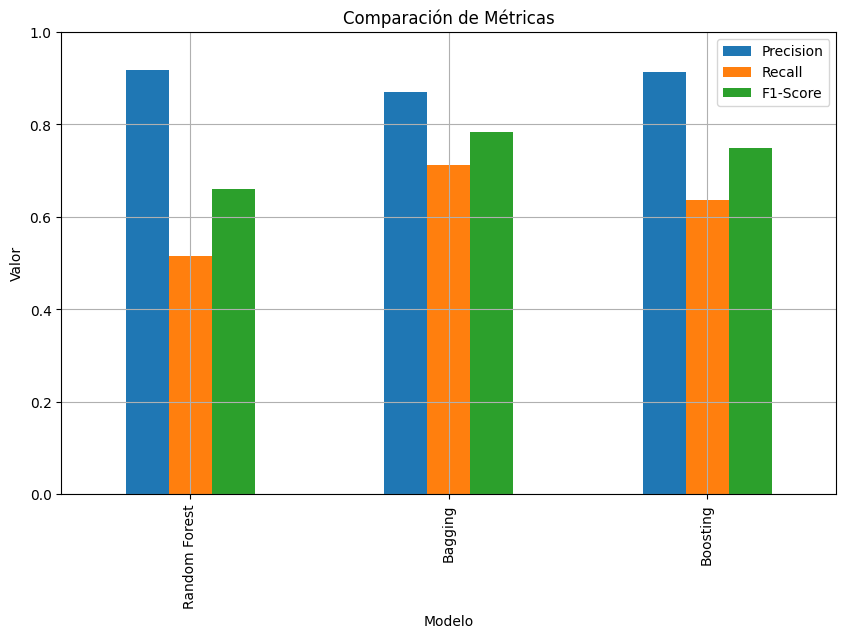

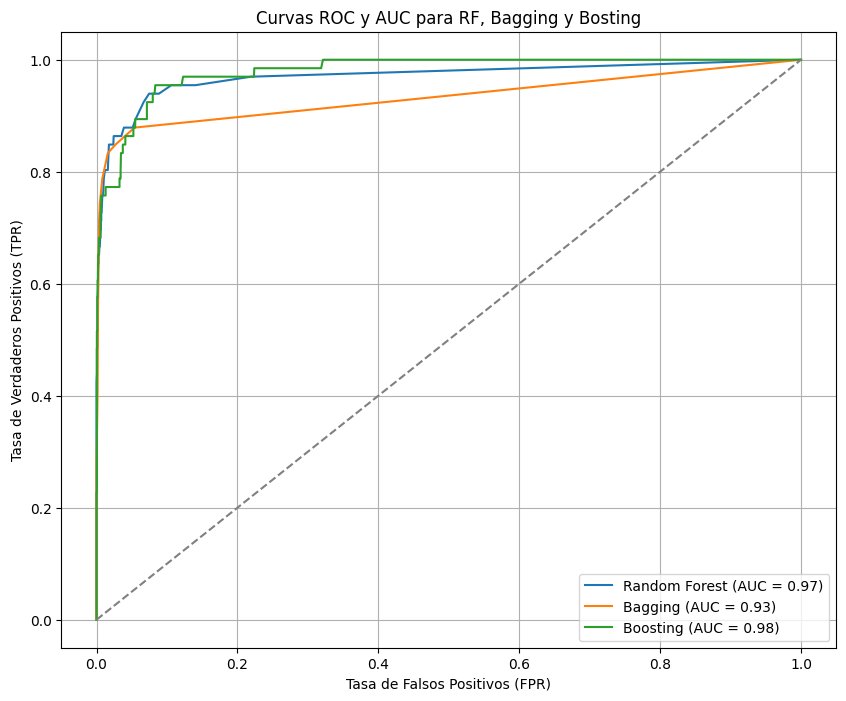

In [ ]:
# Crear gráficos
metrics.plot(x='Modelo', kind='bar', figsize=(10, 6), title='Comparación de Métricas')
plt.ylabel('Valor')
plt.ylim(0, 1)
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Curvas ROC y AUC
plt.figure(figsize=(10, 8))

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')

# Bagging
fpr_bagging, tpr_bagging, _ = roc_curve(y_test, y_prob_bagging)
auc_bagging = auc(fpr_bagging, tpr_bagging)
plt.plot(fpr_bagging, tpr_bagging, label=f'Bagging (AUC = {auc_bagging:.2f})')

# Boosting
fpr_boosting, tpr_boosting, _ = roc_curve(y_test, y_prob_boosting)
auc_boosting = auc(fpr_boosting, tpr_boosting)
plt.plot(fpr_boosting, tpr_boosting, label=f'Boosting (AUC = {auc_boosting:.2f})')

# Configurar el gráfico
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Curvas ROC y AUC para RF, Bagging y Bosting')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

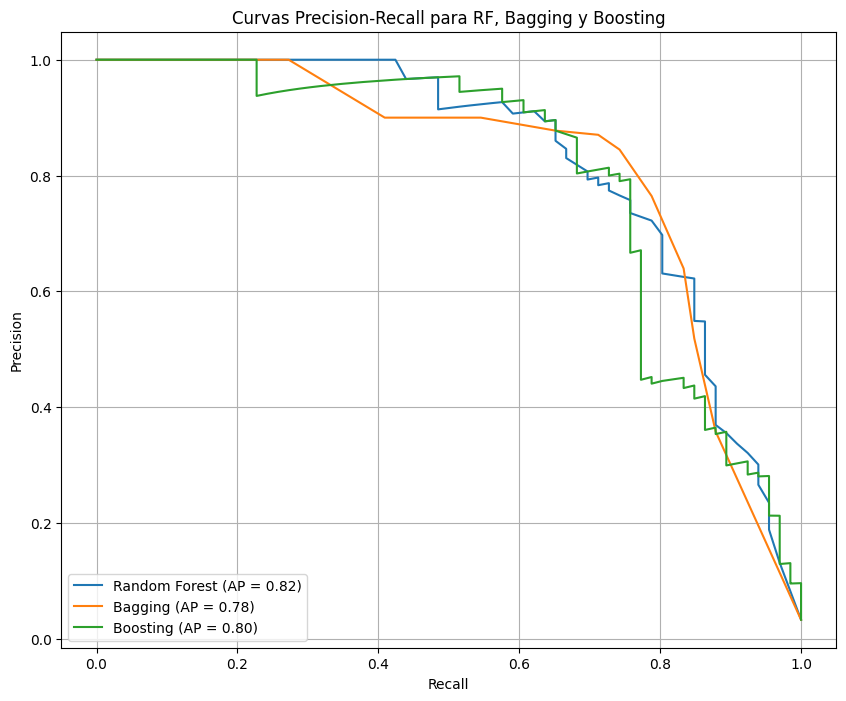

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
avg_precision_rf = average_precision_score(y_test, y_prob_rf)
plt.plot(recall_rf, precision_rf, label=f'Random Forest (AP = {avg_precision_rf:.2f})')

# Bagging
precision_bagging, recall_bagging, _ = precision_recall_curve(y_test, y_prob_bagging)
avg_precision_bagging = average_precision_score(y_test, y_prob_bagging)
plt.plot(recall_bagging, precision_bagging, label=f'Bagging (AP = {avg_precision_bagging:.2f})')

# Boosting
precision_boosting, recall_boosting, _ = precision_recall_curve(y_test, y_prob_boosting)
avg_precision_boosting = average_precision_score(y_test, y_prob_boosting)
plt.plot(recall_boosting, precision_boosting, label=f'Boosting (AP = {avg_precision_boosting:.2f})')

# Configurar el gráfico
plt.title('Curvas Precision-Recall para RF, Bagging y Boosting')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


Al analizar los resultados, observamos que el modelo de Boosting parece ser el más equilibrado cuando consideramos métricas como precisión, recall y F1-Score.

Sin embargo, es importante tener en cuenta que nuestros datos están desbalanceados, lo que podría hacer que la métrica AUC (Área Bajo la Curva ROC) sea menos fiable. Esto se debe a que el AUC se basa en la tasa de falsos positivos (FPR), y en un conjunto de datos con una proporción baja de la clase positiva, la FPR tiende a ser baja, inflando el AUC y dando una falsa impresión de buen desempeño.

Por lo tanto, si mantenemos fijo un umbral de decisión estándar (por ejemplo, 0.5) y priorizamos un balance entre precisión y recall en ese punto, el modelo de Boosting sería una buena opción. Sus métricas de precisión, recall y F1-Score sugieren que realiza predicciones equilibradas y consistentes en ese escenario.

En cambio, si evaluamos el balance entre precisión y recall en un rango completo de umbrales, el Random Forest destaca como una mejor alternativa gracias a su mayor AP (Average Precision). Esta métrica refleja el rendimiento global del modelo a lo largo de todos los umbrales posibles y proporciona una visión más amplia de su capacidad de clasificación.

La selección del mejor modelo dependerá de cómo se implementará en la práctica:

- Boosting es ideal si el umbral de decisión será fijo y las decisiones deben optimizarse para un punto específico.
- Random Forest es más adecuado si necesitamos flexibilidad para ajustar el umbral según diferentes condiciones o prioridades operativas.

Para intentar mejorar más aún el poder de clasificación del modelo, podemos optimizar los hiperparametros

## 5. Optimización de Hiperparámetros

Búsqueda de los mejores hiperparámetros para cada modelo utilizando técnicas como GridSearch o RandomSearch. La métrica a optimizar es el F1-Score.

Esta elección está motivada por las características del caso de uso y las prioridades del negocio.

**Evitar fallos críticos (maximizar recall)**:
Es esencial identificar fallos para evitar daños o interrupciones graves en el sistema.
Aquí, el recall debe ser alto, incluso a costa de predecir fallos cuando no los hay (falsos positivos).

**Minimizar mantenimientos innecesarios (maximizar precisión)**:
Evitar intervenciones costosas o innecesarias en máquinas que funcionan correctamente.
Aquí, la precisión es clave para reducir los falsos positivos.

**Balancear ambas prioridades:**
Tanto fallos no detectados (falsos negativos) como mantenimientos innecesarios (falsos positivos) tienen costos asociados.
El F1 Score es útil para balancear estos costos si tienen un impacto similar.

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# Optimización para Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42), param_grid_rf, cv=5, scoring='f1')
grid_rf.fit(X_train, y_train)
print("Mejor combinación de hiperparámetros para RF:", grid_rf.best_params_)

Mejor combinación de hiperparámetros para RF: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}


In [ ]:
# Optimización para Bagging
param_grid_bagging = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.5, 0.7, 1.0]
}

grid_bagging = GridSearchCV(BaggingClassifier(random_state=42), param_grid_bagging, cv=5, scoring='f1')
grid_bagging.fit(X_train, y_train)
print("Mejor combinación de hiperparámetros para Bagging:", grid_bagging.best_params_)

Mejor combinación de hiperparámetros para Bagging: {'max_samples': 1.0, 'n_estimators': 100}


In [ ]:
# Optimización para Boosting
param_grid_boosting = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

grid_boosting = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_boosting, cv=5, scoring='f1')
grid_boosting.fit(X_train, y_train)
print("Mejor combinación de hiperparámetros para Boosting:", grid_boosting.best_params_)

Mejor combinación de hiperparámetros para Boosting: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}


## 6. Comparación de Resultados


### 6.1 Evaluación y comparación de los resultados de todos los modelos.


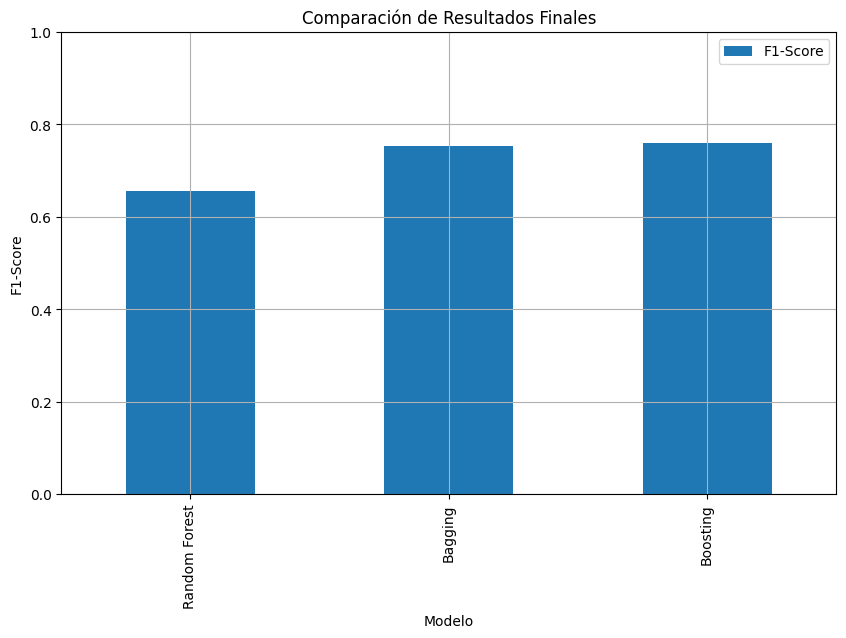

In [ ]:
# Comparar las mejores métricas después de la optimización
final_metrics = pd.DataFrame({
    'Modelo': ['Random Forest', 'Bagging', 'Boosting'],
    'F1-Score': [grid_rf.best_score_, grid_bagging.best_score_, grid_boosting.best_score_]
})

# Visualización de resultados
final_metrics.plot(x='Modelo', kind='bar', figsize=(10, 6), title='Comparación de Resultados Finales')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
plt.legend(loc='best')
plt.grid(True)
plt.show()

### 6.2 Selección del modelo con el mejor rendimiento basado en las métricas obtenidas (una vez ajustados los hiperparámetros).

**Modelo Seleccionado: Bagging.**

Bagging demuestra un rendimiento equilibrado y **ligeramente superior en el F1-Score después de la optimización**.

Bagging es el modelo más adecuado para este caso, ya que logra un buen equilibrio entre precisión y recall, adaptándose mejor al contexto del problema.

Sin embargo, Boosting también podría ser considerado si el objetivo fuera capturar patrones más complejos teniendo en cuenta que requerirá una carga computacional mayor.

## 7. Visualización de los Resultados
  

### Variables más relevantes para el modelo seleccionado.


<ipython-input-50-3fa3573f6d50>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


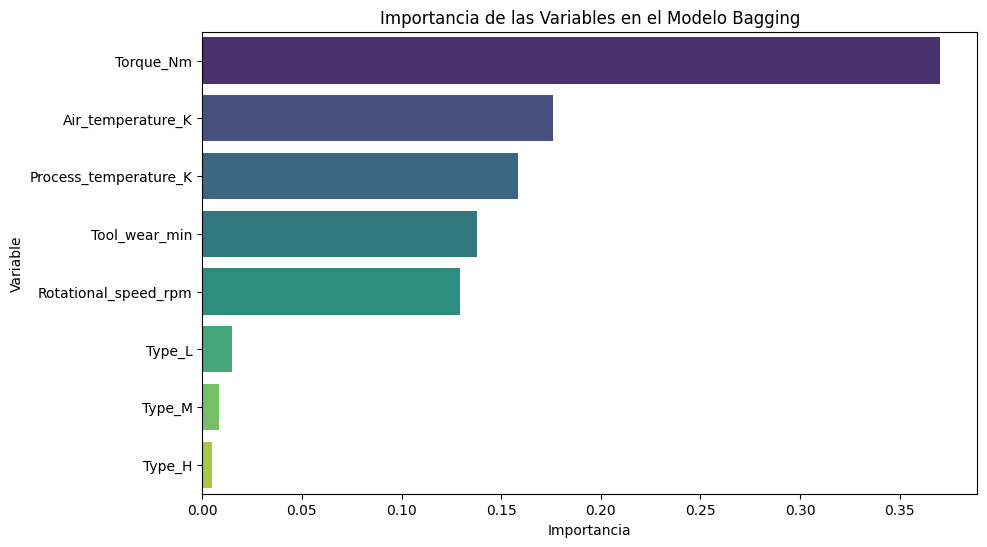

In [ ]:
# Variables más relevantes para el modelo seleccionado (Feature Importance)
importances = np.mean([tree.feature_importances_ for tree in bagging_model.estimators_], axis=0)
features = X.columns

# Crear un gráfico de barras para las importancias de las variables
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Importancia de las Variables en el Modelo Bagging')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()

### Análisis Univariante de las variables usando las predicciones.

In [ ]:
# Añadimos las predicciones al dataset original
X_test_df = pd.DataFrame(X_test, columns=features)
X_test_df['Predicción'] = y_pred_bagging

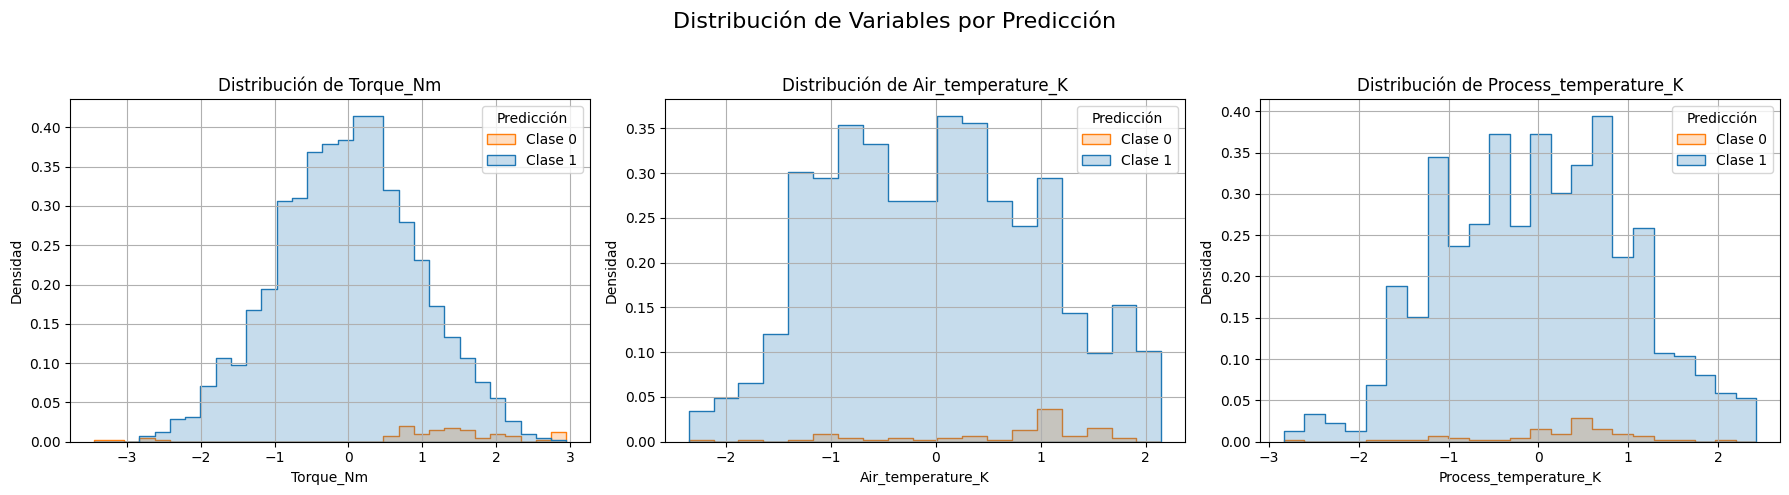

In [ ]:
# @title
# Gráfico de distribución para las variables más importantes
top_features = importance_df['Feature'].head(3)  # Seleccionamos las 3 variables más importantes

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de Variables por Predicción', fontsize=16)

for i, feature in enumerate(top_features):
    sns.histplot(data=X_test_df, x=feature, hue='Predicción', element='step', stat='density', ax=axes[i])
    axes[i].set_title(f'Distribución de {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Densidad')
    axes[i].legend(title='Predicción', labels=['Clase 0', 'Clase 1'])
    axes[i].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 8. (EXTRA) ¿Cómo resolveríais el problema si queréis predecir qué tipo de fallo va a ocurrir? ¿Qué cambia respecto al caso anterior?

In [ ]:
# Separar las características (X) y la variable objetivo (y). En este caso la variable target sea categoría multiclase.
# Convertir la variable objetivo multiclase en categorías numéricas
# Definir el diccionario de mapeo manualmente
mapeo_etiquetas = {
    'No Failure': 0,
    'Heat Dissipation Failure': 1,
    'Power Failure': 2,
    'Overstrain Failure': 3,
    'Tool Wear Failure': 4
}


# Aplicar el mapeo al DataFrame para crear una nueva columna con las etiquetas numéricas
failure['Failure_Type'] = failure['Failure_Type'].map(mapeo_etiquetas)

# Separar las características y la variable objetivo
X = failure.drop(['Target', 'Failure_Type'], axis=1)
y = failure['Failure_Type']

<ipython-input-53-fcfba17ede7b>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  failure['Failure_Type'] = failure['Failure_Type'].map(mapeo_etiquetas)


In [ ]:
# Escalamos las variables numéricas
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Para las variables categóricas, usamos codificación one-hot
X = pd.get_dummies(X, columns=categorical_cols)

In [ ]:
# División en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Modelo 1: Random Forest
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
# Evaluación del modelo
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1929
           1       0.83      0.45      0.59        22
           2       1.00      0.53      0.69        19
           3       0.80      0.50      0.62        16
           4       0.00      0.00      0.00         9

    accuracy                           0.98      1995
   macro avg       0.72      0.50      0.58      1995
weighted avg       0.97      0.98      0.98      1995

Confusion Matrix:
 [[1927    2    0    0    0]
 [  11   10    0    1    0]
 [   8    0   10    1    0]
 [   8    0    0    8    0]
 [   9    0    0    0    0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score

In [ ]:
# Modelo 2: XGBoost
# Calcular los pesos de las clases inversamente proporcionales a su frecuencia
class_weights = {cls: len(y_train) / (len(np.unique(y_train)) * np.bincount(y_train)[cls])
                 for cls in np.unique(y_train)}

# Asignar el peso correspondiente a cada instancia en el conjunto de entrenamiento
sample_weight = np.array([class_weights[label] for label in y_train])

xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train, sample_weight=sample_weight)

# Realizar predicciones
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [ ]:
# Evaluar el modelo
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1929
           1       0.78      0.95      0.86        22
           2       0.79      1.00      0.88        19
           3       0.76      0.81      0.79        16
           4       0.09      0.11      0.10         9

    accuracy                           0.98      1995
   macro avg       0.68      0.77      0.72      1995
weighted avg       0.98      0.98      0.98      1995

Confusion Matrix:
 [[1906    6    4    3   10]
 [   0   21    0    1    0]
 [   0    0   19    0    0]
 [   2    0    1   13    0]
 [   8    0    0    0    1]]


In [ ]:
# También podemos mostrar el AUC utilizando el método OVR (One vs the rest)
from sklearn.preprocessing import label_binarize
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
roc_auc = roc_auc_score(y_test_binarized, xgb_model.predict_proba(X_test), average="weighted", multi_class="ovr")
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9889703776214221


Como tenemos los datos muy desbalanceados nos interesa también calcular el AP (Área bajo la curva Precision-Recall). Para poder calcular el AP y el AUC necesitamos binarizar el problemna. Uno de los métodos es OVR (One vs the Rest) donde para cada categoría separamos en 0 (si pertenece a otra categoría que no es esa) y 1 (si pertenece a esa categoría).

In [ ]:
from sklearn.preprocessing import label_binarize

def evaluate_multiclass_model(model, X_test, y_test):
    """
    Evalúa un modelo de clasificación multiclase y calcula:
      - ROC-AUC utilizando el método OVR (One vs Rest)
      - Average Precision (Macro)

    Parámetros:
        model: Modelo entrenado (debe tener un método `predict_proba`)
        X_test: Conjunto de características para la evaluación
        y_test: Etiquetas reales de las clases

    Devuelve:
        Un diccionario con:
          - "roc_auc": Valor ROC-AUC ponderado
          - "average_precision_macro": Average Precision (Macro)
    """
    # Binarizar las clases
    y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))

    # Obtener probabilidades predichas
    y_proba = model.predict_proba(X_test)

    # Calcular ROC-AUC ponderado
    roc_auc = roc_auc_score(y_test_binarized, y_proba, average="weighted", multi_class="ovr")

    # Calcular Average Precision por clase
    average_precision_per_class = []
    for i in range(y_test_binarized.shape[1]):
        precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_proba[:, i])
        average_precision = average_precision_score(y_test_binarized[:, i], y_proba[:, i])
        average_precision_per_class.append(average_precision)

    # Calcular el promedio macro de Average Precision
    average_precision_macro = np.mean(average_precision_per_class)

    # Retornar resultados
    return {
        "roc_auc": roc_auc,
        "average_precision_macro": average_precision_macro
    }


In [ ]:
# Llamada a la función con el Random Forest
resultados_rf = evaluate_multiclass_model(rf_model, X_test, y_test)
print("ROC-AUC:", resultados_rf["roc_auc"])
print("Average Precision (Macro):", resultados_rf["average_precision_macro"])

ROC-AUC: 0.9690625843486264
Average Precision (Macro): 0.7182611256844867


In [ ]:
# Llamada a la función con el XGBoost
resultados_xgb = evaluate_multiclass_model(xgb_model, X_test, y_test)
print("ROC-AUC:", resultados_xgb["roc_auc"])
print("Average Precision (Macro):", resultados_xgb["average_precision_macro"])

ROC-AUC: 0.9889703776214221
Average Precision (Macro): 0.7637716203782017


Una vez calculadas las métricas de evaluación podemos sacar las siguientes conclusiones:

##**1. Problemática del caso de uso**

El dataset está altamente desbalanceado. La mayoría de los datos pertenecen a la clase 0 ("No Failure"), que representa el 96% del total, mientras que las clases restantes tienen una presencia mínima:

Clase 1 ("Heat Dissipation Failure"): 1.1%

Clase 2 ("Power Failure"): 0.95%

Clase 3 ("Overstrain Failure"): 0.78%

Clase 4 ("Tool Wear Failure"): 0.45%

Este desbalance presenta un desafío significativo, ya que las clases minoritarias son las más importantes para la predicción del fallo.

##**2. Desempeño General**

Ambos modelos alcanzan una precisión global (accuracy) del 98%, pero este valor está fuertemente influenciado por la clase mayoritaria.

**XGBoost demuestra ser superior en términos de métricas globales**

`ROC-AUC`: 0.989 (XGBoost) vs. 0.969 (Random Forest), lo que indica que XGBoost discrimina mejor entre las clases.

`Average Precision (Macro)`: 0.764 (XGBoost) vs. 0.718 (Random Forest), reflejando un mejor equilibrio en las predicciones de todas las clases.

##**3. Desempeño por Clase**

`Clase 0 ("No Failure")`:
Ambos modelos funcionan excepcionalmente bien en esta clase mayoritaria.
Random Forest logra un recall perfecto (1.00), mientras que XGBoost tiene un recall de 0.99.

`Clases Minoritarias (1, 2, 3, 4)`:
XGBoost sobresale en todas las clases minoritarias, superando significativamente a Random Forest:

`Clase 1 ("Heat Dissipation Failure")`:

XGBoost: Recall 95%, F1-score 0.86.

Random Forest: Recall 45%, F1-score 0.59.

`Clase 2 ("Power Failure")`:
XGBoost: Recall perfecto (100%), F1-score 0.88.

Random Forest: Recall 53%, F1-score 0.69.

`Clase 3 ("Overstrain Failure")`:

XGBoost: Recall 81%, F1-score 0.79.

Random Forest: Recall 50%, F1-score 0.62.

`Clase 4 ("Tool Wear Failure")`:

XGBoost logra clasificar correctamente 1 caso con un recall de 11% y F1-score de 0.10, mientras que Random Forest no predice correctamente ninguna instancia (recall y F1-score de 0.00).

##**4. Limitaciones Identificadas**

`Clase 4 ("Tool Wear Failure")`:

Ambas matrices de confusión muestran que los modelos tienen serias dificultades con esta clase debido a su representación extremadamente baja (0.45% del dataset).

Random Forest clasifica todas las instancias como la clase mayoritaria (0), mientras que XGBoost logra identificar un caso correctamente.

Esto refleja que los modelos requieren ajustes adicionales, como técnicas de rebalanceo o penalización de errores en clases minoritarias, para mejorar en esta clase. O recoger más datos para esa clase en concreto.

##**5. Interpretación de la Matriz de Confusión**

XGBoost comete menos errores en las clases minoritarias, lo que se traduce en métricas significativamente mejores para estas clases.

Random Forest tiende a sobreclasificar instancias hacia la clase mayoritaria, fallando más frecuentemente en las clases críticas.

##**6. Conclusión Final**

XGBoost es el modelo más adecuado para este problema, ya que gestiona mejor el desbalance de datos y tiene un desempeño consistentemente superior en las clases minoritarias (1, 2 y 3).

Random Forest funciona excepcionalmente bien para la clase mayoritaria (No Failure) pero es significativamente inferior para el resto de clases.

##**7.Recomendaciones**

Probar con diferentes hiperparámetros y algoritmos para mejorar el rendimiento del modelo (como en el caso anterior)